# Question 2: VGG16 from scratch (MNIST / CIFAR10 / CIFAR100)

## Setup

In [1]:

# Setup: imports, seeds, device

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Reproducibility


SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Device


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)

print("PyTorch version     :", torch.__version__)
print("Torchvision version :", torchvision.__version__)
print("NumPy version       :", np.__version__)
print("Pandas version      :", pd.__version__)

print("Using device        :", device)

if torch.cuda.is_available():
    print("GPU                 :", torch.cuda.get_device_name(0))
    print(
        "GPU Memory          :",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("GPU                 : Not available")
    print(" Training will run on CPU.")

QUICK_TEST = False

print("Quick test mode     :", QUICK_TEST)



SETUP COMPLETE
PyTorch version     : 2.11.0+cu128
Torchvision version : 0.26.0+cu128
NumPy version       : 2.1.3
Pandas version      : 2.2.3
Using device        : cuda
GPU                 : Tesla T4
GPU Memory          : 14.56 GB
Quick test mode     : False


## Data loading & preprocessing

In [2]:

# Data loading & preprocessing


DATASET_INFO = {
    'MNIST':    {'num_classes': 10,  'grayscale': True},
    'CIFAR10':  {'num_classes': 10,  'grayscale': False},
    'CIFAR100': {'num_classes': 100, 'grayscale': False},
}

def build_transform(grayscale):
    steps = []
    if grayscale:
        steps.append(transforms.Grayscale(num_output_channels=3))
        steps.append(transforms.Resize((32, 32)))
    steps.append(transforms.ToTensor())
    steps.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
    return transforms.Compose(steps)

def get_dataloaders(dataset_name, batch_size=32, data_root='./data', quick_test=False):
    info = DATASET_INFO[dataset_name]
    transform = build_transform(info['grayscale'])

    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=transform)
        classes = [str(i) for i in range(10)]
    elif dataset_name == 'CIFAR10':
        train_set = torchvision.datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    elif dataset_name == 'CIFAR100':
        train_set = torchvision.datasets.CIFAR100(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR100(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    else:
        raise ValueError(f"Unknown dataset {dataset_name}")

    if quick_test:
        train_set = Subset(train_set, range(1024))
        test_set = Subset(test_set, range(512))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, info['num_classes'], classes


## Model definition

In [3]:

# Model:

VGG16_CFG = [64, 64, 'M',
             128, 128, 'M',
             256, 256, 256, 'M',
             512, 512, 512, 'M',
             512, 512, 512, 'M']


def make_vgg_layers(cfg, in_channels=3, batch_norm=True):
    layers = []
    channels = in_channels
    for v in cfg:
        if v == 'M':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            layers.append(nn.Conv2d(channels, v, kernel_size=3, padding=1))
            if batch_norm:
                layers.append(nn.BatchNorm2d(v))
            layers.append(nn.ReLU(inplace=True))
            channels = v
    return nn.Sequential(*layers)


class VGG16(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, cfg=VGG16_CFG):
        super().__init__()
        self.features = make_vgg_layers(cfg, in_channels=in_channels)

        final_channels = [c for c in cfg if c != 'M'][-1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(final_channels, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x   # raw logits


model = VGG16(num_classes=10)
print(model)


VGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 2

## Training & evaluation utilities

In [4]:

# Training loop

def train_model(model, train_loader, epochs=10, lr=0.01, device=device, verbose=True):
    model.to(device)
    # momentum=0.9 is a standard SGD hyperparameter (still 'the SGD optimizer'
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    model.train()
    history = []
    start = time.time()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        epoch_loss, epoch_acc = running_loss / total, correct / total
        history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'train_acc': epoch_acc})
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs} | loss: {epoch_loss:.4f} | train acc: {epoch_acc:.4f}")

    training_time = time.time() - start
    if verbose:
        print(f"Training time: {training_time:.2f} seconds")
    return history, training_time


def evaluate_model(model, test_loader, device=device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    print(f"Test Accuracy: {metrics['accuracy']:.4f} | Precision: {metrics['precision']:.4f} "
          f"| Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}")
    return metrics


def visualize_prediction(model, test_loader, classes, device=device, unnormalize=True):
    dataset = test_loader.dataset
    idx = np.random.randint(len(dataset))
    image, label = dataset[idx]

    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()

    img = image.permute(1, 2, 0).cpu().numpy()
    if unnormalize:
        img = img * 0.5 + 0.5
    plt.figure(figsize=(3, 3))
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True: {classes[label]} | Predicted: {classes[pred]}", fontsize=10)
    plt.axis('off')
    plt.show()


def plot_confusion_matrix(model, test_loader, classes, device=device, dataset_name=''):
    """Second visualization technique (alongside the single-image prediction
    above): a confusion matrix over the full test set, showing per-class
    error patterns rather than just one example."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig_size = 4 if len(classes) <= 10 else 8   # bigger canvas for CIFAR100's 100 classes
    plt.figure(figsize=(fig_size, fig_size))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion matrix — {dataset_name}", fontsize=10)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    if len(classes) <= 10:
        plt.xticks(range(len(classes)), classes, rotation=45, ha='right', fontsize=7)
        plt.yticks(range(len(classes)), classes, fontsize=7)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## Train & evaluate across MNIST, CIFAR10, CIFAR100


===== VGG16 (from scratch) | Dataset: MNIST =====
Epoch  1/10 | loss: 0.2182 | train acc: 0.9384
Epoch  2/10 | loss: 0.0633 | train acc: 0.9861
Epoch  3/10 | loss: 0.0455 | train acc: 0.9897
Epoch  4/10 | loss: 0.0374 | train acc: 0.9918
Epoch  5/10 | loss: 0.0269 | train acc: 0.9939
Epoch  6/10 | loss: 0.0232 | train acc: 0.9945
Epoch  7/10 | loss: 0.0203 | train acc: 0.9953
Epoch  8/10 | loss: 0.0184 | train acc: 0.9957
Epoch  9/10 | loss: 0.0148 | train acc: 0.9966
Epoch 10/10 | loss: 0.0119 | train acc: 0.9972
Training time: 511.65 seconds
Test Accuracy: 0.9949 | Precision: 0.9948 | Recall: 0.9949 | F1: 0.9948


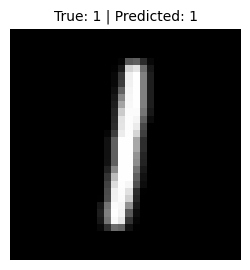

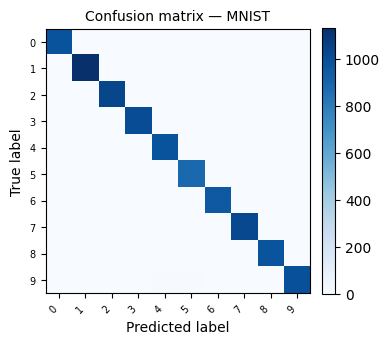


===== VGG16 (from scratch) | Dataset: CIFAR10 =====
Epoch  1/10 | loss: 1.7222 | train acc: 0.3350
Epoch  2/10 | loss: 1.2835 | train acc: 0.5531
Epoch  3/10 | loss: 0.9879 | train acc: 0.6750
Epoch  4/10 | loss: 0.8078 | train acc: 0.7415
Epoch  5/10 | loss: 0.6783 | train acc: 0.7864
Epoch  6/10 | loss: 0.5835 | train acc: 0.8173
Epoch  7/10 | loss: 0.5037 | train acc: 0.8418
Epoch  8/10 | loss: 0.4341 | train acc: 0.8656
Epoch  9/10 | loss: 0.3725 | train acc: 0.8835
Epoch 10/10 | loss: 0.3178 | train acc: 0.9015
Training time: 381.94 seconds
Test Accuracy: 0.8419 | Precision: 0.8424 | Recall: 0.8419 | F1: 0.8408


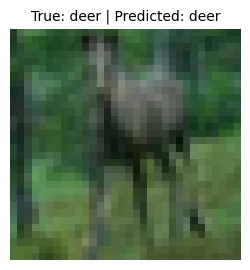

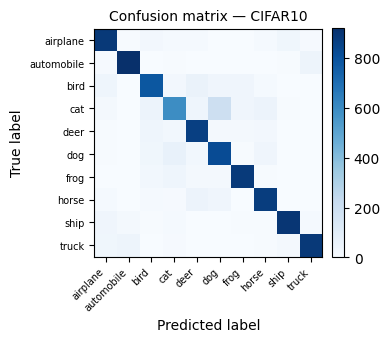


===== VGG16 (from scratch) | Dataset: CIFAR100 =====


100%|██████████| 169M/169M [00:12<00:00, 13.3MB/s]


Epoch  1/10 | loss: 4.3656 | train acc: 0.0248
Epoch  2/10 | loss: 4.0812 | train acc: 0.0458
Epoch  3/10 | loss: 3.7864 | train acc: 0.0757
Epoch  4/10 | loss: 3.5117 | train acc: 0.1125
Epoch  5/10 | loss: 3.2697 | train acc: 0.1533
Epoch  6/10 | loss: 3.0551 | train acc: 0.1920
Epoch  7/10 | loss: 2.8510 | train acc: 0.2318
Epoch  8/10 | loss: 2.6606 | train acc: 0.2703
Epoch  9/10 | loss: 2.4795 | train acc: 0.3111
Epoch 10/10 | loss: 2.3284 | train acc: 0.3457
Training time: 375.71 seconds
Test Accuracy: 0.3606 | Precision: 0.3582 | Recall: 0.3606 | F1: 0.3326


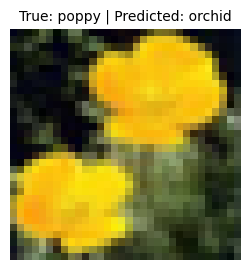

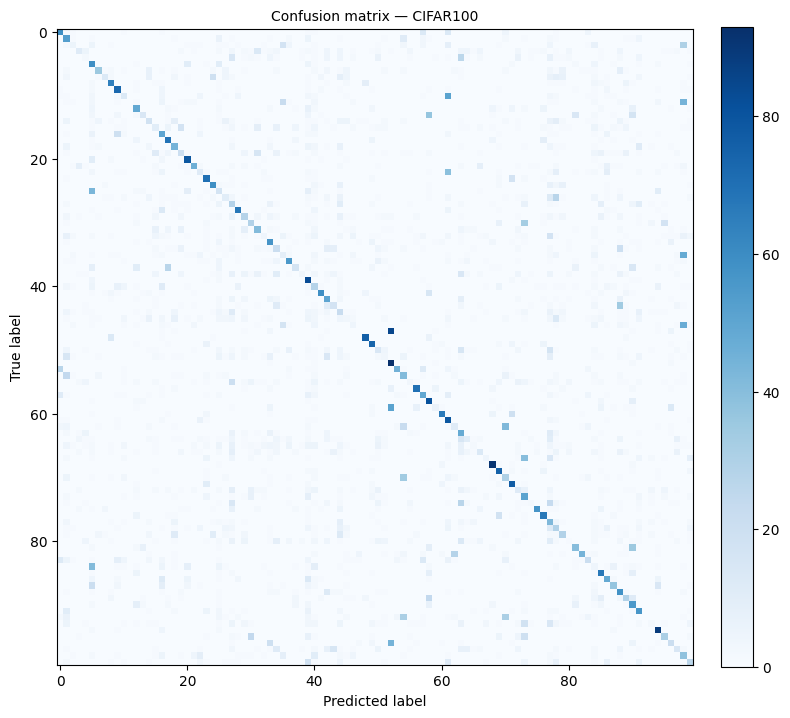


===== Summary: VGG16 =====
          accuracy  precision    recall        f1  training_time_sec
MNIST       0.9949   0.994803  0.994907  0.994847         511.652192
CIFAR10     0.8419   0.842442  0.841900  0.840762         381.936149
CIFAR100    0.3606   0.358165  0.360600  0.332607         375.713714


In [5]:

# Running Question 2 across all three datasets


EPOCHS = 2 if QUICK_TEST else 10

results = {}
for ds_name in ['MNIST', 'CIFAR10', 'CIFAR100']:
    print(f"\n===== VGG16 (from scratch) | Dataset: {ds_name} =====")
    train_loader, test_loader, num_classes, classes = get_dataloaders(
        ds_name, batch_size=32, quick_test=QUICK_TEST
    )
    model = VGG16(num_classes=num_classes)

    history, train_time = train_model(model, train_loader, epochs=EPOCHS, lr=0.01)
    metrics = evaluate_model(model, test_loader)
    metrics['training_time_sec'] = train_time
    results[ds_name] = metrics

    visualize_prediction(model, test_loader, classes)
    plot_confusion_matrix(model, test_loader, classes, dataset_name=ds_name)

summary_df = pd.DataFrame(results).T
print("\n===== Summary: VGG16 =====")
print(summary_df)


## Ablation study


--- Config: VGG11 (fewer conv layers) ---
Test Accuracy: 0.7711 | Precision: 0.7831 | Recall: 0.7711 | F1: 0.7686

--- Config: VGG16 (full, fewer filters) ---
Test Accuracy: 0.7695 | Precision: 0.7802 | Recall: 0.7695 | F1: 0.7689

--- Config: VGG16 (full, standard filters) ---
Test Accuracy: 0.7630 | Precision: 0.7779 | Recall: 0.7630 | F1: 0.7622

===== Ablation summary: conv depth / filter count (CIFAR10) =====
                                accuracy  precision  recall        f1
VGG11 (fewer conv layers)         0.7711   0.783141  0.7711  0.768574
VGG16 (full, fewer filters)       0.7695   0.780237  0.7695  0.768891
VGG16 (full, standard filters)    0.7630   0.777915  0.7630  0.762211


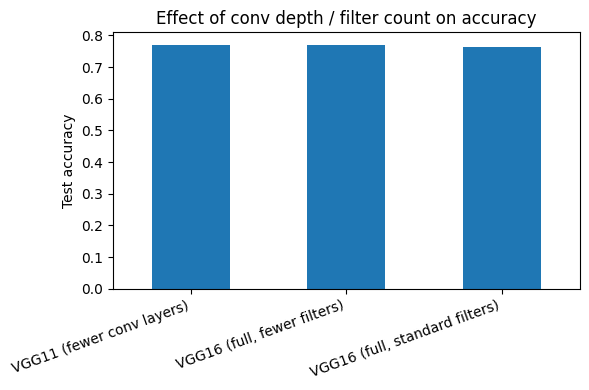

In [6]:

# Ablation study


ablation_epochs = 2 if QUICK_TEST else 5

VGG11_CFG = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']  # fewer conv layers
VGG16_NARROW_CFG = [c // 2 if isinstance(c, int) else c for c in VGG16_CFG]     # half the filters

configs = {
    'VGG11 (fewer conv layers)': VGG11_CFG,
    'VGG16 (full, fewer filters)': VGG16_NARROW_CFG,
    'VGG16 (full, standard filters)': VGG16_CFG,
}

train_loader, test_loader, num_classes, classes = get_dataloaders(
    'CIFAR10', batch_size=32, quick_test=QUICK_TEST
)

ablation_results = {}
for name, cfg in configs.items():
    print(f"\n--- Config: {name} ---")
    model = VGG16(num_classes=num_classes, cfg=cfg)
    _, _ = train_model(model, train_loader, epochs=ablation_epochs, lr=0.01, verbose=False)
    metrics = evaluate_model(model, test_loader)
    ablation_results[name] = metrics

ablation_df = pd.DataFrame(ablation_results).T
print("\n===== Ablation summary: conv depth / filter count (CIFAR10) =====")
print(ablation_df)

ablation_df['accuracy'].plot(kind='bar', figsize=(6, 4), title='Effect of conv depth / filter count on accuracy')
plt.ylabel('Test accuracy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()




### Discussion: convolutional layers and filters

- **More convolutional layers** (VGG16 vs VGG11) increase the receptive
  field and let the network build more abstract, hierarchical features
  before classification, generally improving accuracy at the cost of more
  parameters, more computation, and a higher risk of vanishing gradients
  during optimisation with plain SGD.
- **More filters per layer** increase the variety of patterns each layer
  can detect (edges, textures, object parts), which typically helps
  accuracy but increases memory/compute cost roughly linearly (or worse)
  per layer, and can overfit small datasets like this fixed 10-epoch
  budget without enough regularisation.
- Compared with the Q1 feed-forward network, convolution's key advantage
  is **weight sharing and translation invariance**: a filter that detects
  an edge in one part of the image is reused everywhere, which is far
  more parameter-efficient than a fully-connected layer over raw pixels.


### 2 Analysis: VGG16 (CNN)

Receptive Fields & Filter Depth: VGG16 utilizes small $3
\times 3$ convolutional filters stacked sequentially to retain a small local receptive field while building deep representation hierarchies. Increasing filter channels in deeper layers allows the network to progress from low-level features (edges, textures) in early layers to complex class-specific semantics in deeper layers.Parameter Density: The inclusion of large fully connected (FC) classification layers at the top of VGG16 accounts for the majority of the model's total parameters. This architecture significantly increases memory consumption and training time compared to newer convolutional designs that utilize global average pooling.